In [1]:
# Standard Libraries
import os
import io
import math
import time
import monai
from pytorch_msssim import ssim
import random
import tempfile
import warnings
from multiprocessing import Manager
from typing import Optional
from tqdm.notebook import tqdm
from monai.config import USE_COMPILED
from monai.networks.blocks import Warp, DVF2DDF
dvf_to_ddf = DVF2DDF()
# Third-party Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import SimpleITK as sitk
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torchio as tio
from torch.utils.data import DataLoader, Dataset, random_split
from torch.cuda.amp import GradScaler, autocast

# MONAI Libraries
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader

from monai.utils import set_determinism

# Custom Libraries
from generative.inferers import DiffusionInferer
from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler

import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (8192, rlimit[1]))

# Configuration
sitk.ProcessObject.SetGlobalDefaultThreader("Platform")
warnings.filterwarnings('ignore')


JUPYTER_ALLOW_INSECURE_WRITES=True

# Seed and Device Configuration
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CUDA and CUDNN Configuration
# Uncomment the following line to specify CUDA_VISIBLE_DEVICES
# os.environ['CUDA_VISIBLE_DEVICES'] = '2,3,5,6'
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


/home1/zamzam/.local/lib/python3.11/site-packages/monai/networks/blocks/warp.py:72: UserWarning: monai.networks.blocks.Warp: Using PyTorch native grid_sample.
  warnings.warn("monai.networks.blocks.Warp: Using PyTorch native grid_sample.")
/home1/zamzam/3D_lesion_DF/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/home1/zamzam/3D_lesion_DF/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
from monai.networks.blocks import Convolution

model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_channels=[32, 64, 64],
    attention_levels=[False, False,True],
    num_head_channels=[0, 0,32],
    num_res_blocks=2,
)
model_filename = '/scratch1/zamzam/models/model_large_epoch999.pt'

model.to(device)

model = nn.DataParallel(model)

model.load_state_dict(torch.load(model_filename)) 
scheduler = DDPMScheduler(num_train_timesteps=1000, schedule="scaled_linear_beta", beta_start=0.0005, beta_end=0.0195)

inferer = DiffusionInferer(scheduler)

original_conv1 = model.module.conv_in
new_conv1 = Convolution(
            spatial_dims=3,
            in_channels=2,
            out_channels=original_conv1.out_channels,
            strides=1,
            kernel_size=3,
            padding=1,
            conv_only=True,
        )

# # Create a new conv layer with 3 input channels and the same output channels, kernel size, etc.
# new_conv1 = nn.Conv2d(3, original_conv1.out_channels, kernel_size=original_conv1.kernel_size, 
#                       stride=original_conv1.stride, padding=original_conv1.padding)

# Copy the weights from the original channel
with torch.no_grad():
    new_conv1.conv.weight[:, :1, :, :,:] = original_conv1.conv.weight.clone()  # Copy weights for the original channel
    # Initialize the weights for the new channels to zero
    new_conv1.conv.weight[:, 1:, :, :,:].zero_()  # Zero out weights for the additional channels
    new_conv1.conv.bias = torch.nn.Parameter(original_conv1.conv.bias.clone())


# Replace the original conv1 layer with the new one
model.module.conv_in = new_conv1
model = model.to(device)

model_filename ='/scratch1/zamzam/akrami/small_net/model_inpaint_smart_ir_epoch800.pt'
model.load_state_dict(torch.load(model_filename)) 

<All keys matched successfully>

In [3]:
import SimpleITK as sitk

def sitk_reader(path):

    image_nii = sitk.ReadImage(str(path), sitk.sitkFloat32)
    vol = sitk.GetArrayFromImage(image_nii).transpose(2, 1, 0)
    return vol, None
    
def read_nifti(file, mask = None, df = False):
    vol_image = tio.ScalarImage(file, reader=sitk_reader)
    vol_array = vol_image.numpy()
    normalized_vol_array, peak = normalize_by_peak(vol_array)
    
    data = {
        'img_path': [file],
        'peak': [peak],
        'age': [50],
        'ID' : [1],
        'img_name' : [file],
        'mask_path' : [mask] if mask is not None else [file],
        'seg_path' : [mask] if mask is not None else [file]
    }
    
    dataframe = pd.DataFrame(data)
    
    input_data = Eval(dataframe,config)
    input_loader = DataLoader(input_data, batch_size=1,shuffle=True,num_workers=8)
    
    
    input_subject = next(iter(input_loader))
    
    input = input_subject['vol']['data']
    
    peak_expanded = (input_subject['peak'].unsqueeze(1).unsqueeze(2).unsqueeze(3).unsqueeze(4)).long()
    peak_expanded = peak_expanded

    misc = input_subject['seg']['data'].float()
    
    # Perform the division if we're not reading a deformation field
    if not df and (peak_expanded != 0).all():
        input = (input / peak_expanded)
        
    
    if mask is None:
        return input
    else:
        return input, misc

def normalize_by_peak(image):
    # Calculate histogram, ignoring first bin
    image[image < 0] = 0
    hist, bins = np.histogram(image, bins=20)

    # Find the peak of the histogram
    peak = bins[np.argmax(hist[1:]) + 1]  # Adding 1 to exclude the first bin
    # print(peak)

    # Normalize the image by the peak
    normalized_image = image / peak

    return normalized_image, peak

def Eval(csv, cfg):
    subjects = []
    for _, sub in csv.iterrows():
        if (
            sub.mask_path is not None
            and tio.ScalarImage(sub.img_path, reader=sitk_reader).shape
            != tio.ScalarImage(sub.mask_path, reader=sitk_reader).shape
        ):
            print(
                f"different shapes of vol and mask detected. Shape vol: {tio.ScalarImage(sub.img_path,reader=sitk_reader).shape}, shape mask: {tio.ScalarImage(sub.mask_path,reader=sitk_reader).shape} \nsamples will be resampled to the same dimension"
            )

        vol_image = tio.ScalarImage(sub.img_path, reader=sitk_reader)

        # Apply histogram normalization here
        subject_dict = {
            "vol": vol_image,
            "peak": sub.peak,  # Store the peak value
            "seg": tio.LabelMap(sub.seg_path, reader=sitk_reader, type=tio.LABEL),
            "age": sub.age,
            "ID": sub.img_name,
            "path": sub.img_path,
        }
        # if sub.mask_path is not None:  # if we have masks
        #     subject_dict["mask"] = tio.LabelMap(sub.mask_path, reader=sitk_reader)

        subject = tio.Subject(subject_dict)
        subjects.append(subject)
    ds = tio.SubjectsDataset(subjects, transform=get_eval_transform(cfg))
    return ds

def get_eval_transform(cfg):  # only transforms that are applied once before preloading
    exclude_from_resampling = None
    h, w, d = tuple(cfg.get("imgDimResize", (160, 192, 160)))
    if cfg.get("unisotropic_sampling", True):
        preprocess = tio.Compose(
            [
                tio.CropOrPad((h, w, d), padding_mode=0),
                tio.Resample(
                    cfg.get("rescaleFactor", 3.0),
                    image_interpolation="bspline",
                    exclude=exclude_from_resampling,
                ),
            ]
        )

    else:
        print("dummy")

    return preprocess

config = {
    'batch_size': 1,
    'imgDimResize': (160, 192, 160),
    'imgDimPad': (208, 256, 208),
    'spatialDims': '3D',
    'unisotropic_sampling': True,
    'perc_low': 1,
    'perc_high': 99,
    'rescaleFactor': 2,
    'base_path': '/scratch1/akrami/Latest_Data/Data',
}

In [4]:

subject = '/scratch1/zamzam/Strokes/Preprocessed/final/t1/sub-r040s030_ses-1_space-MNI152NLin2009aSym_t1.nii.gz'
lesion = '/scratch1/zamzam/Strokes/Preprocessed/cut/seg/sub-r040s030_ses-1_space-MNI152NLin2009aSym_seg.nii.gz'

x, mask = read_nifti(subject, mask = lesion)


Text(0.5, 1.0, 'Brain Image')

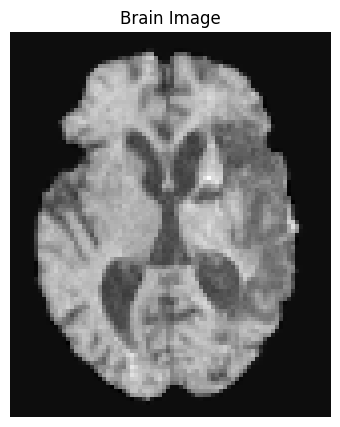

In [5]:
import matplotlib.pyplot as plt
import numpy as np


# Plot and log the warped image and DDF on WandB
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
middle_slice_idx = x.shape[4] // 2  # Assuming 3D image with shape (B, C, H, W, D)

# Warped Image
axs.imshow(np.rot90(x[0, 0, :, :, middle_slice_idx].cpu().numpy(), k=-1), cmap="gray")
axs.axis("off")
axs.set_title("Brain Image")

  0%|          | 0/1000 [00:00<?, ?it/s]

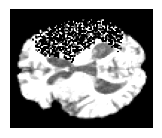

In [6]:
masks= 1-mask.to(device)
image = x.to(device)

current_img = torch.randn_like(image).to(device)

maked_input = image*masks+(1-masks)* current_img 
combined_tensor = torch.cat(( maked_input,masks), dim=1).to(dtype=torch.float32)
scheduler.set_timesteps(num_inference_steps=1000)
progress_bar = tqdm(scheduler.timesteps)
middle_slice_idx = image.size(-1) // 2
plt.figure(figsize=(2, 2))
plt.imshow(maked_input[0, 0, :, :, middle_slice_idx].cpu()*2, vmin=0, vmax=2, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()
for t in progress_bar:  # go through the noising process
    with autocast(enabled=False):
        with torch.no_grad():
            model_output = model(combined_tensor, timesteps=torch.Tensor((t,)).to(image.device))
            current_img, _ = scheduler.step(
                model_output, t, maked_input
            )  # this is the prediction x_t at the time step t
            maked_input = image*masks+(1-masks)* current_img
            combined_tensor = torch.cat(( maked_input,masks), dim=1).to(dtype=torch.float32)



(-0.5, 79.5, 95.5, -0.5)

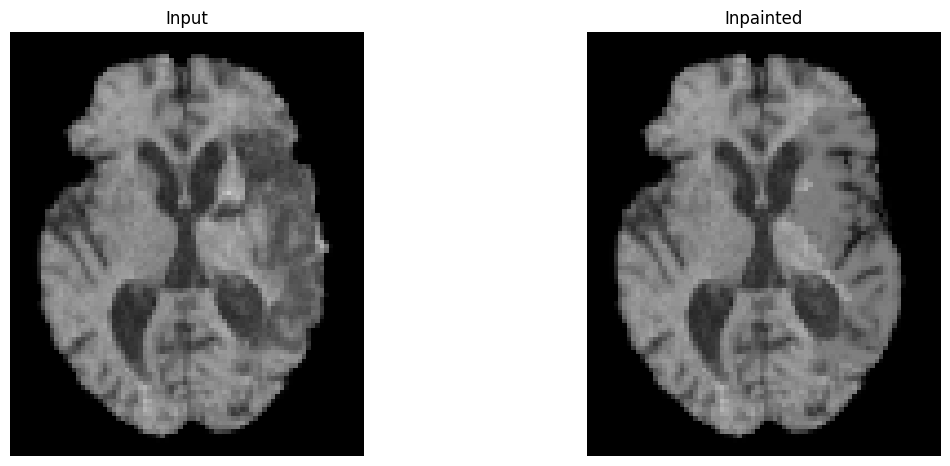

In [7]:
# Plot and log the warped image and x side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

middle_slice_idx = maked_input.shape[4] // 2  # D // 2

# x
axs[0].imshow(
    np.rot90(image[0, 0, :, :, middle_slice_idx].cpu().numpy(), k=-1), vmin=0, vmax=2,
    cmap="gray"
)
axs[0].set_title("Input")
axs[0].axis("off")

plt.tight_layout()

# maked_input
axs[1].imshow(
    np.rot90(maked_input[0, 0, :, :, middle_slice_idx].cpu().numpy(), k=-1), vmin=0, vmax=2,
    cmap="gray"
)
axs[1].set_title("Inpainted")
axs[1].axis("off")


In [9]:
import os
from glob import glob
from pathlib import Path

import torch
from tqdm.notebook import tqdm
import nibabel as nib
from torch.cuda.amp import autocast

# -----------------------
# Paths
# -----------------------
T1_DIR   = "/scratch1/zamzam/Strokes/Preprocessed/final/t1/"
SEG_DIR  = "/scratch1/zamzam/Strokes/Preprocessed/cut/seg/"
OUT_DIR  = "/scratch1/zamzam/Strokes/inpainted/"

os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------
# Helpers
# -----------------------
def infer_mask_path(t1_path: str, seg_dir: str) -> str:
    """
    Masks have the same base name as the image, but end with _seg.nii.gz.
    Handles t1 files that end with _t1.nii.gz or _T1w.nii.gz.
    """
    name = Path(t1_path).name
    if name.endswith("_t1.nii.gz"):
        mask_name = name.replace("_t1.nii.gz", "_seg.nii.gz")
    elif name.endswith("_T1w.nii.gz"):
        mask_name = name.replace("_T1w.nii.gz", "_seg.nii.gz")
    else:
        # fallback: replace extension and append _seg
        mask_name = name.replace(".nii.gz", "_seg.nii.gz")

    return os.path.join(seg_dir, mask_name)

def strip_modality_suffix(filename_no_ext: str) -> str:
    """
    Given a filename stem (no .nii.gz), remove trailing modality suffix if present.
    e.g., ..._T1w -> ...
          ..._t1  -> ...
    """
    stem = filename_no_ext
    for suf in ("_T1w", "_t1"):
        if stem.endswith(suf):
            stem = stem[: -len(suf)]
            break
    return stem

def save_downsampled_nifti(ref_nii_path: str, vol_b1c: torch.Tensor, out_path: str, ds_factor: int = 2):
    """
    Save a (B, C, H, W, D) tensor as NIfTI, using ref_nii_path for orientation,
    but fixing voxel spacing (affine + zooms) to match a downsample by ds_factor.

    Assumes B=1, C=1.
    """
    ref = nib.load(ref_nii_path)

    affine = ref.affine.copy()
    affine[:3, :3] *= ds_factor  # downsample by 2 -> voxel size doubles

    header = ref.header.copy()
    zooms = header.get_zooms()
    header.set_zooms((zooms[0] * ds_factor, zooms[1] * ds_factor, zooms[2] * ds_factor))

    vol = vol_b1c.detach().float().cpu().numpy()[0, 0]  # (H, W, D)
    header.set_data_dtype(vol.dtype)

    nib.save(nib.Nifti1Image(vol, affine, header), out_path)

# -----------------------
# Main loop
# -----------------------
t1_files = sorted(glob(os.path.join(T1_DIR, "*.nii.gz")))
if len(t1_files) == 0:
    raise RuntimeError(f"No .nii.gz files found in: {T1_DIR}")

for subject_path in tqdm(t1_files, desc="Inpainting subjects"):
    mask_path = infer_mask_path(subject_path, SEG_DIR)
    if not os.path.exists(mask_path):
        print(f"[SKIP] Missing mask for {Path(subject_path).name}: {mask_path}")
        continue

    # read_nifti downsamples by a factor of 2 (per your note)
    x, mask = read_nifti(subject_path, mask=mask_path)

    image = x.to(device)
    masks = (1 - mask).to(device)  # keep your convention

    # init
    current_img = torch.randn_like(image, device=device)

    maked_input = image * masks + (1 - masks) * current_img
    combined_tensor = torch.cat((maked_input, masks), dim=1).to(dtype=torch.float32)

    # diffusion loop
    scheduler.set_timesteps(num_inference_steps=1000)
    for t in tqdm(scheduler.timesteps, leave=False):
        with torch.no_grad():
            with autocast(enabled=False):
                model_output = model(
                    combined_tensor,
                    timesteps=torch.tensor((t,), device=image.device)
                )
                current_img, _ = scheduler.step(model_output, t, maked_input)

                maked_input = image * masks + (1 - masks) * current_img
                combined_tensor = torch.cat((maked_input, masks), dim=1).to(dtype=torch.float32)

    # -----------------------
    # Save outputs
    # -----------------------
    name = Path(subject_path).name
    stem0 = name.replace(".nii.gz", "")
    stem = strip_modality_suffix(stem0)

    out_x   = os.path.join(OUT_DIR, f"{stem}_T1w.nii.gz")
    out_inp = os.path.join(OUT_DIR, f"{stem}_inpainted.nii.gz")

    save_downsampled_nifti(subject_path, image, out_x, ds_factor=2)
    save_downsampled_nifti(subject_path, maked_input, out_inp, ds_factor=2)


Inpainting subjects:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

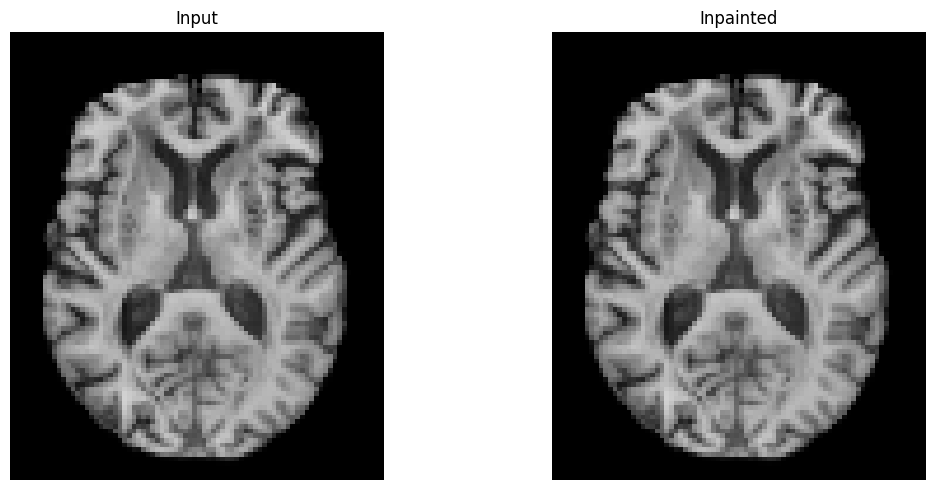

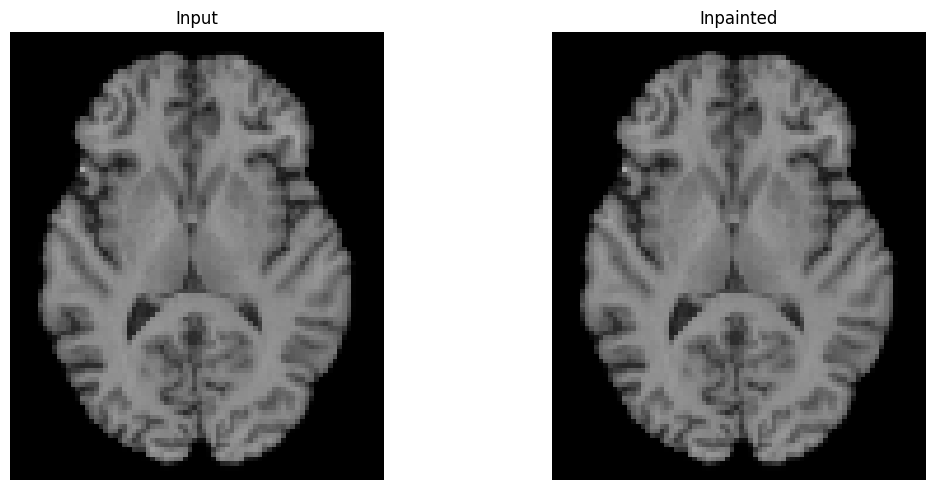

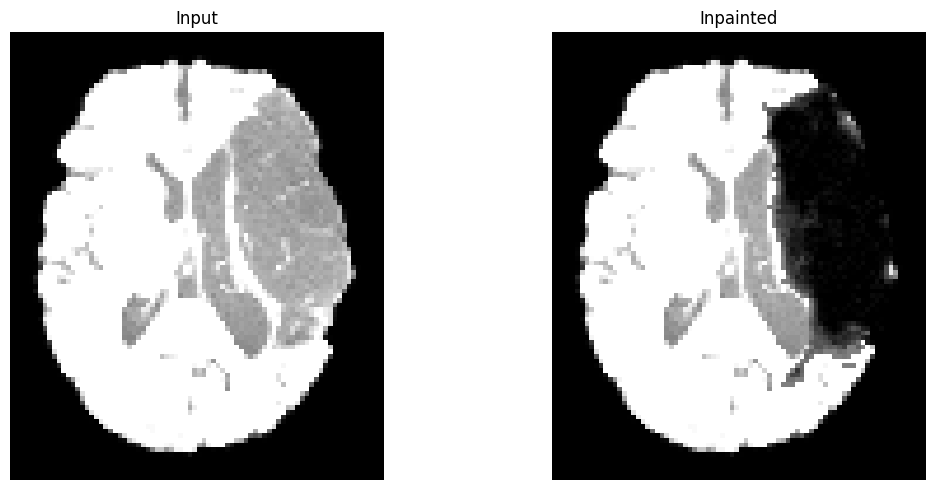

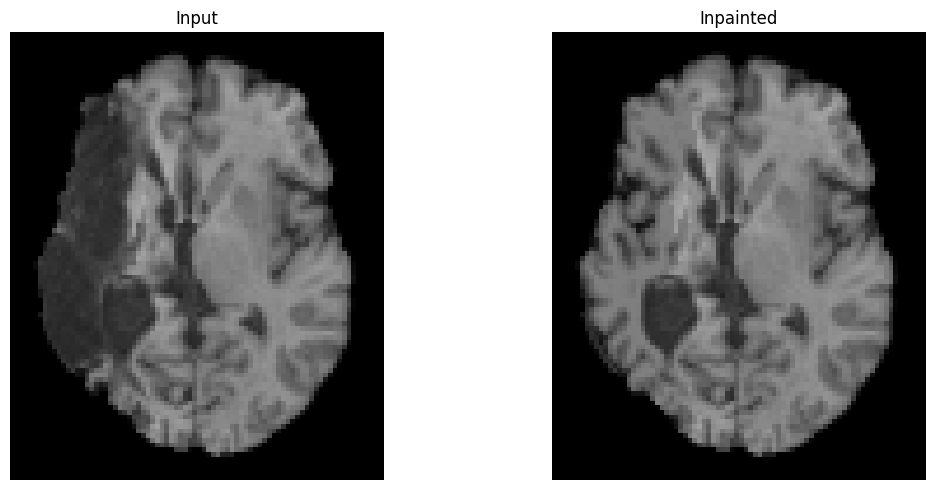

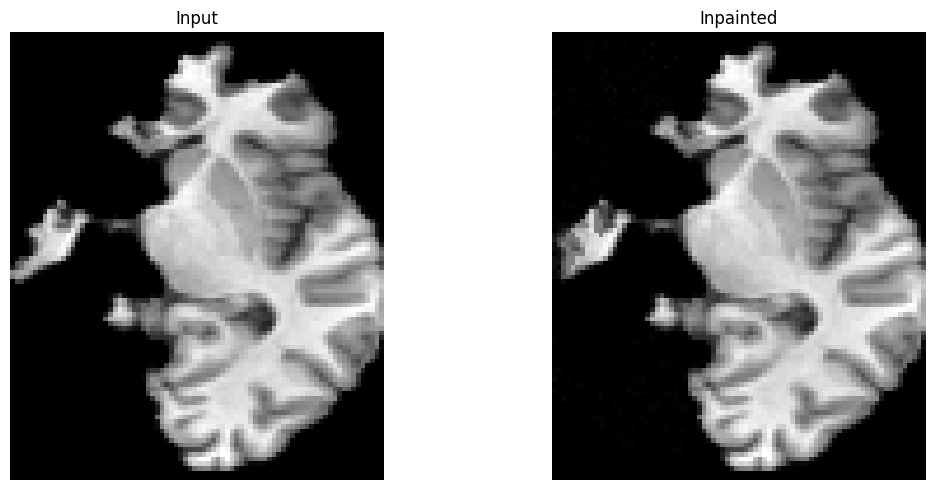

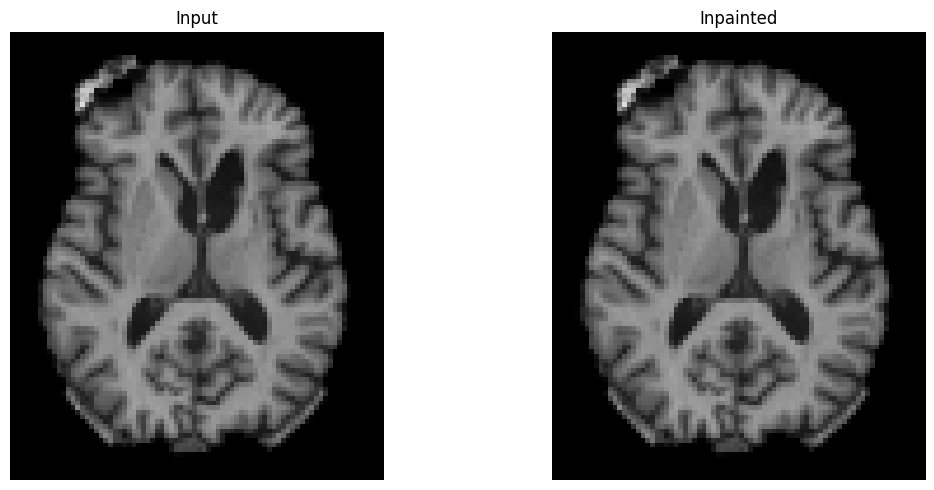

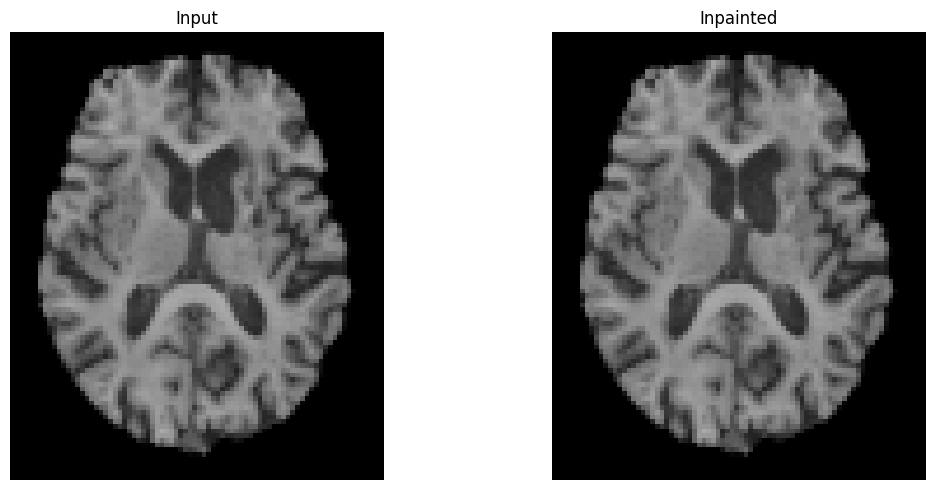

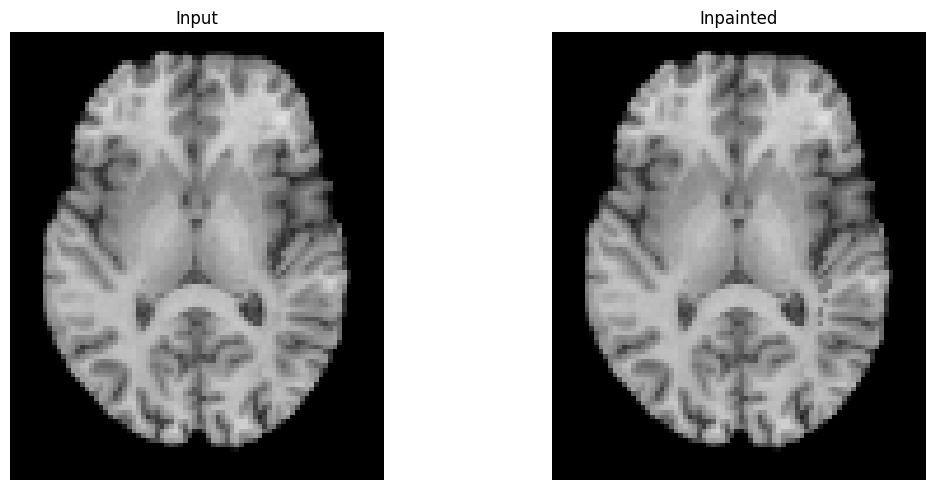

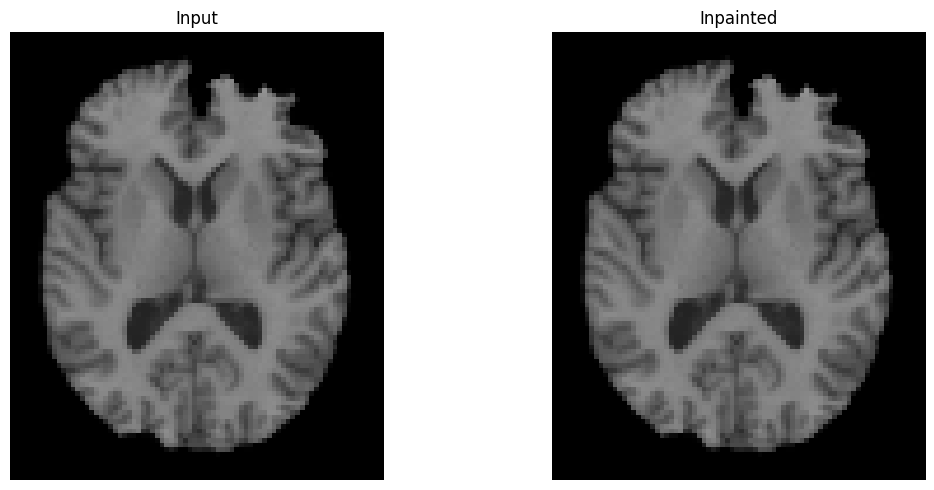

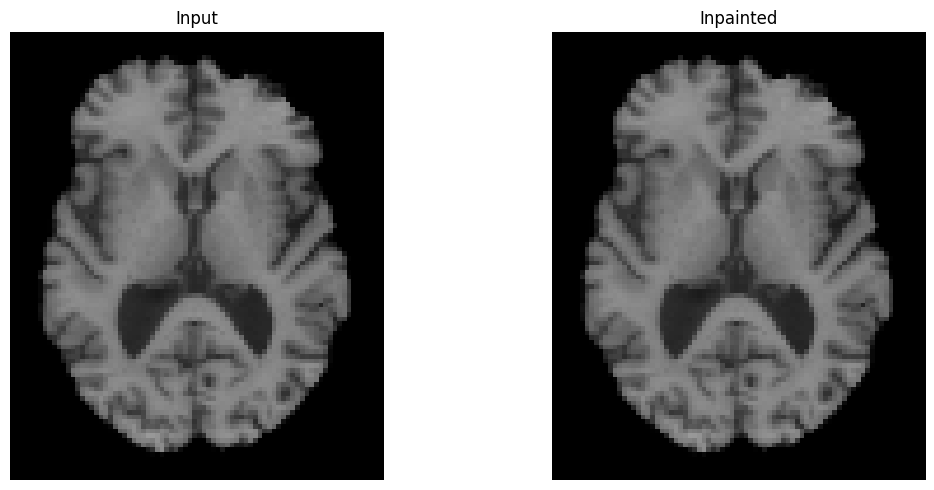

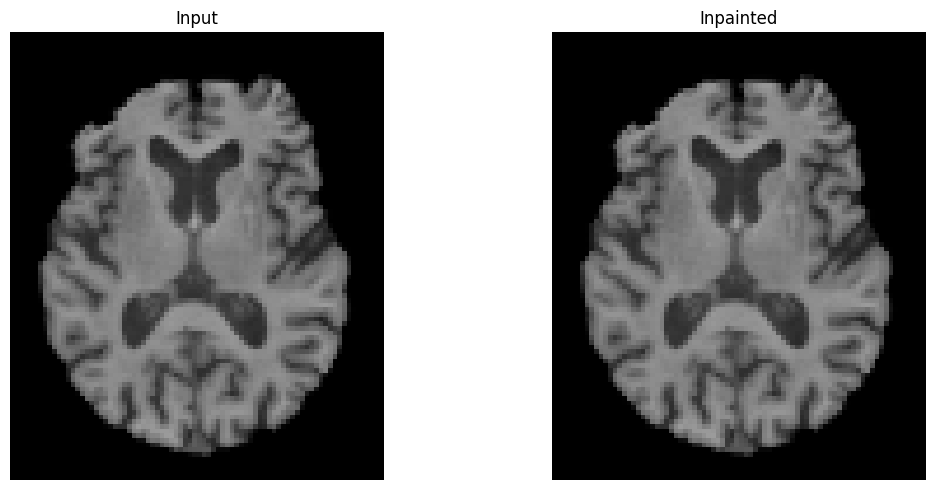

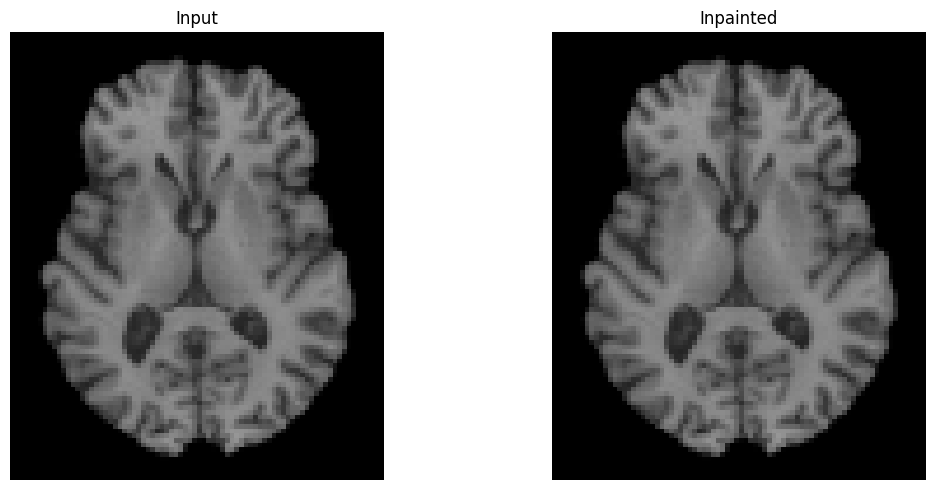

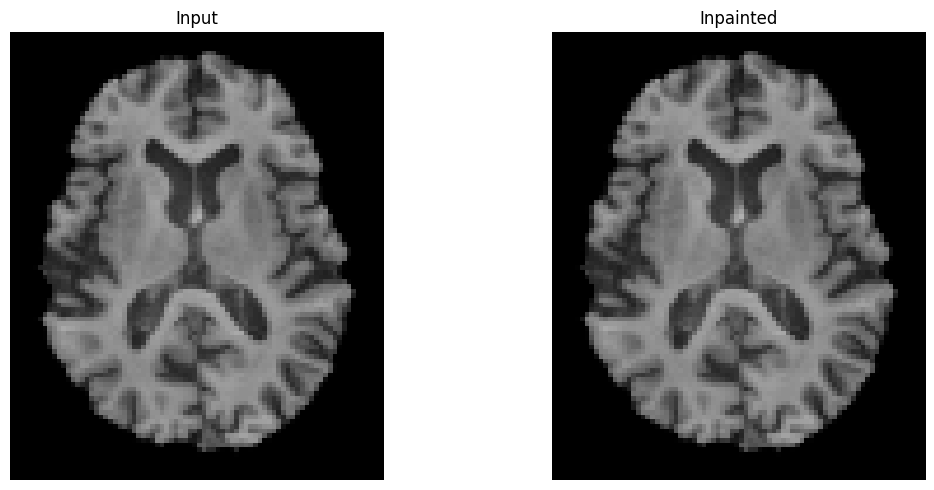

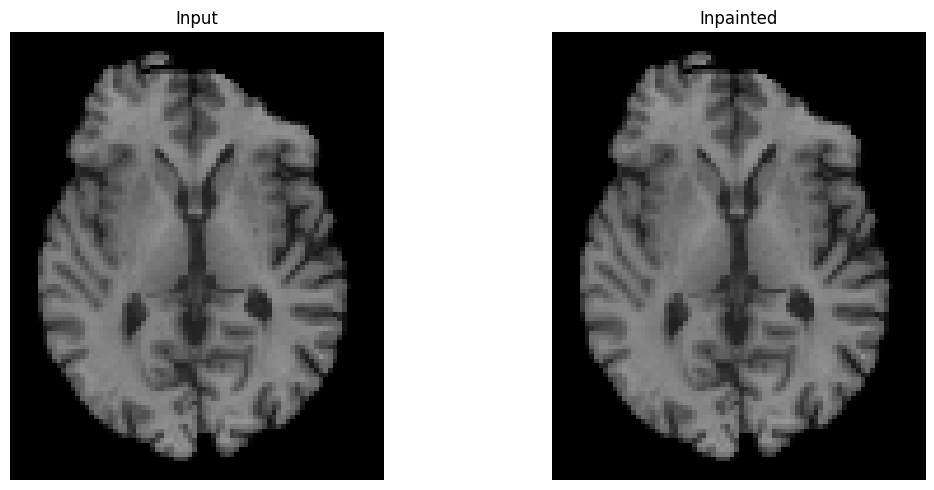

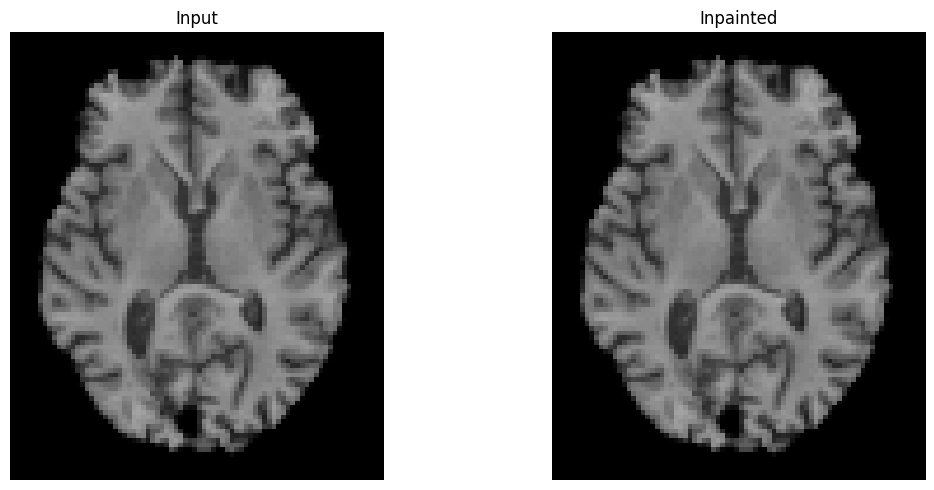

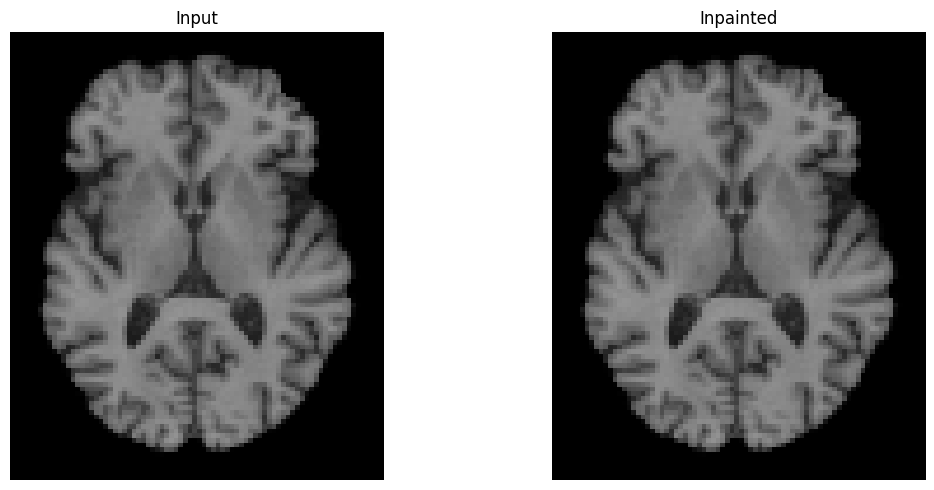

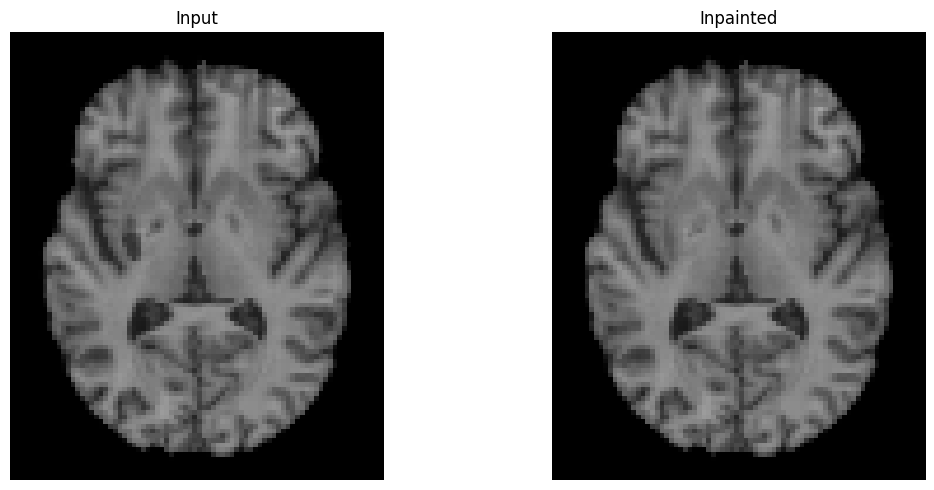

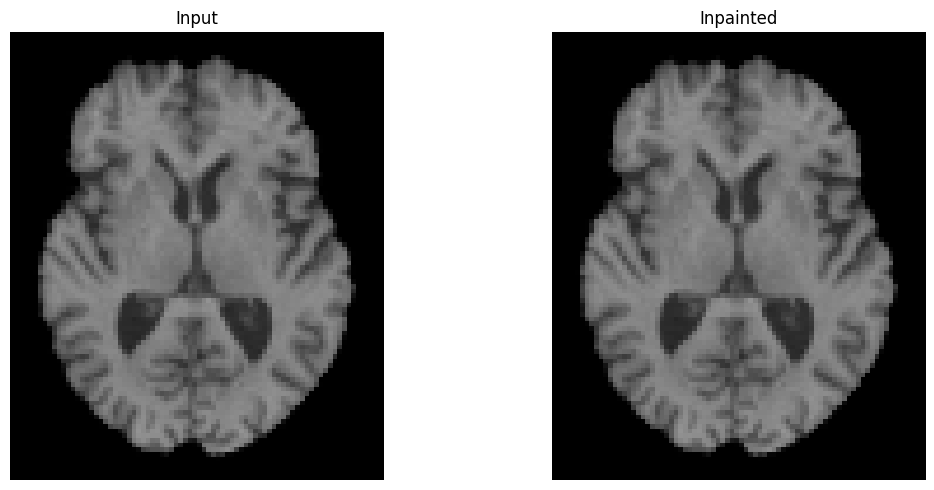

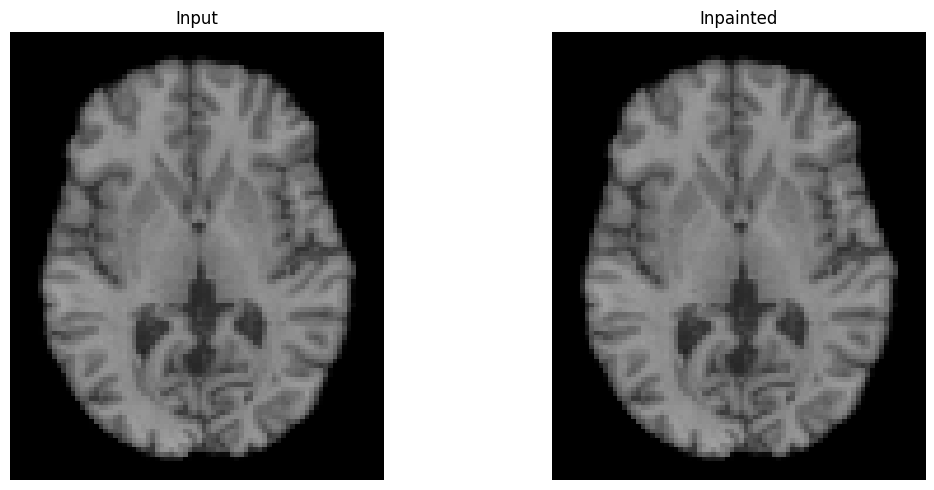

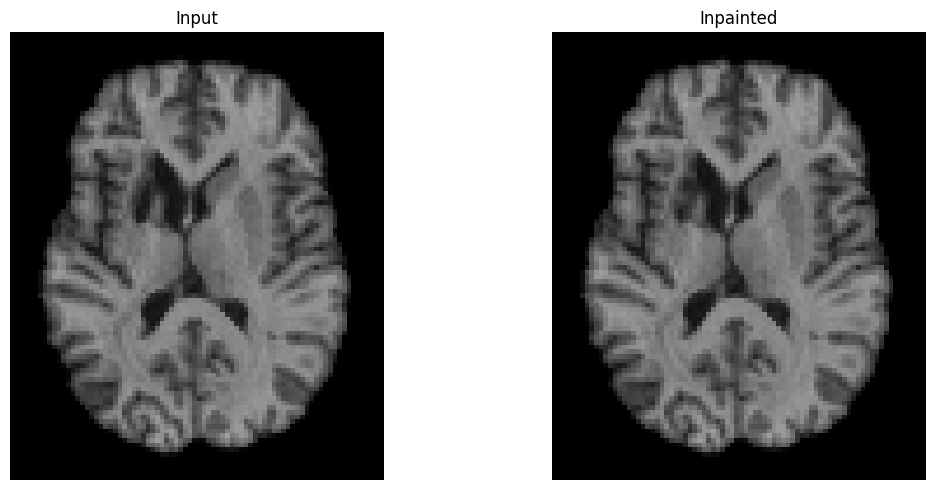

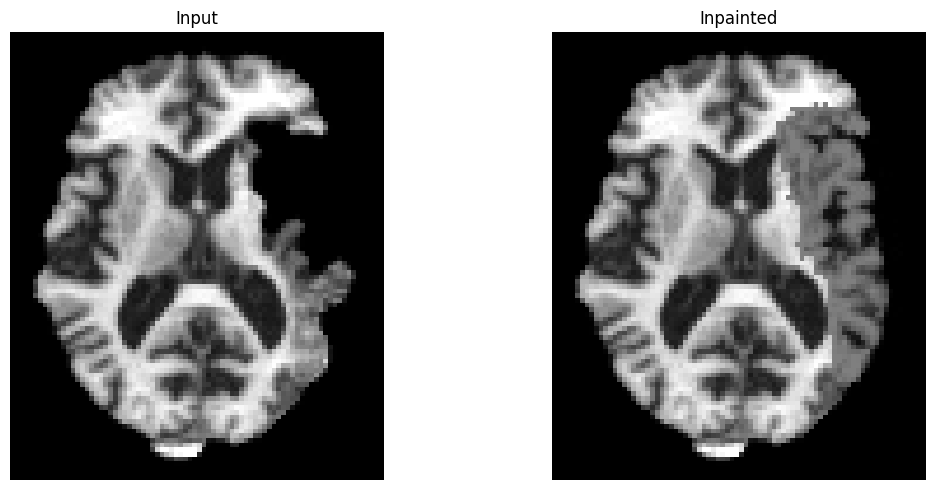

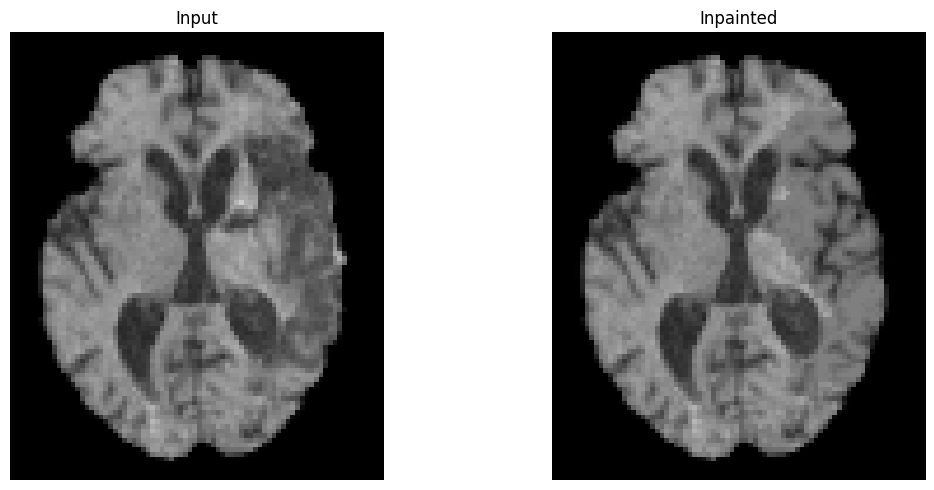

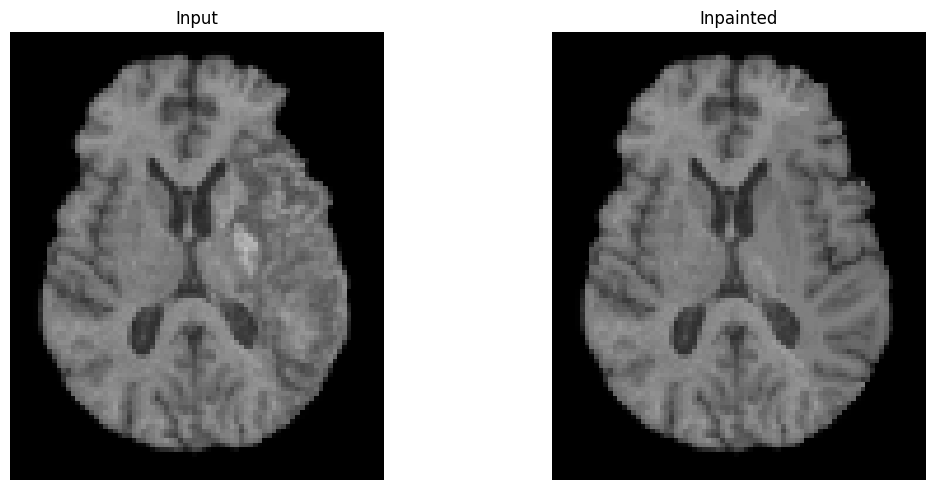

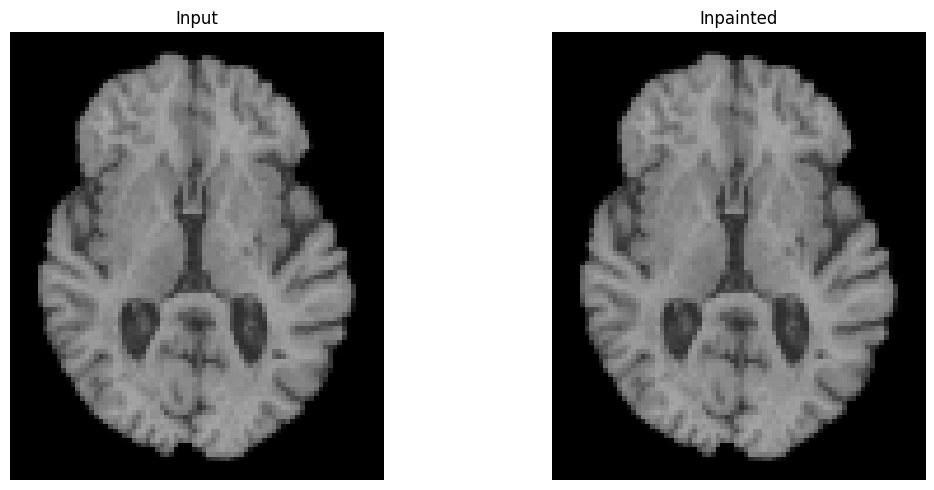

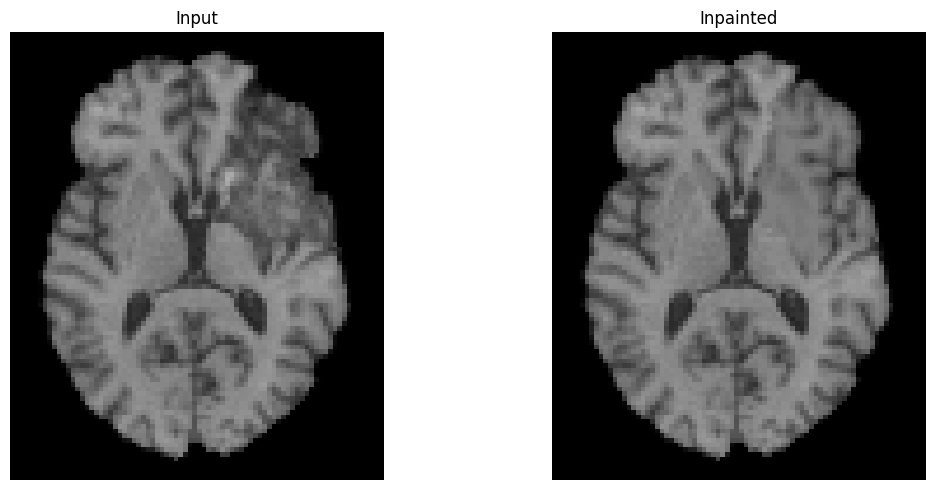

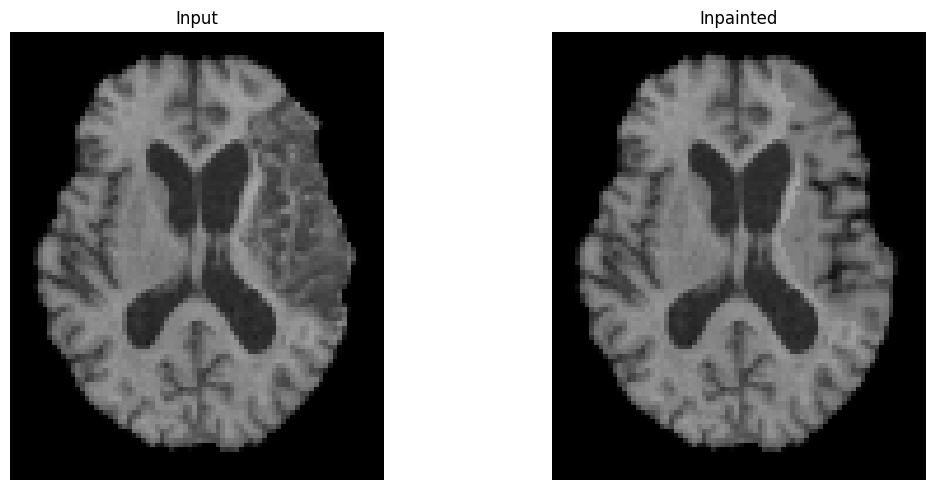

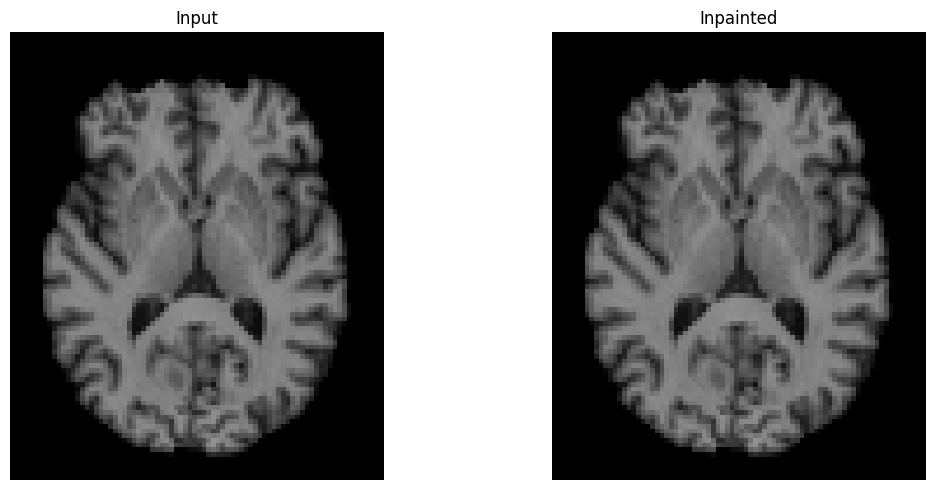

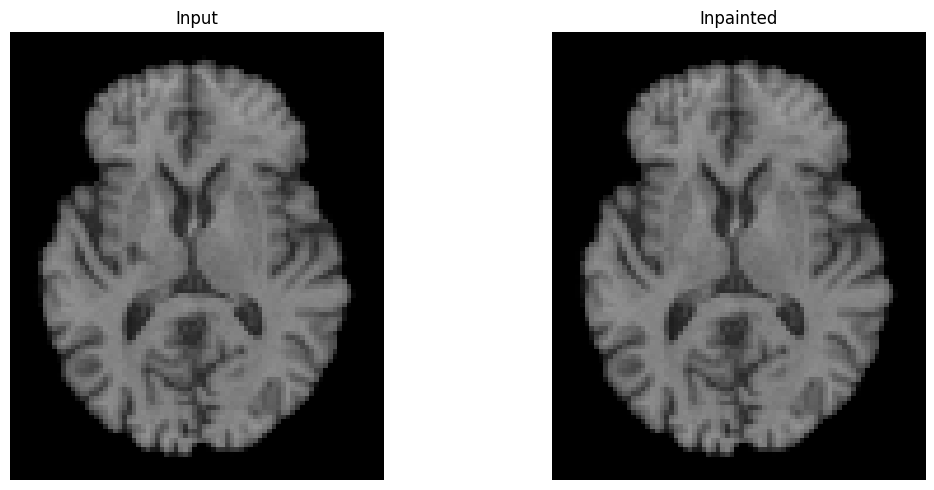

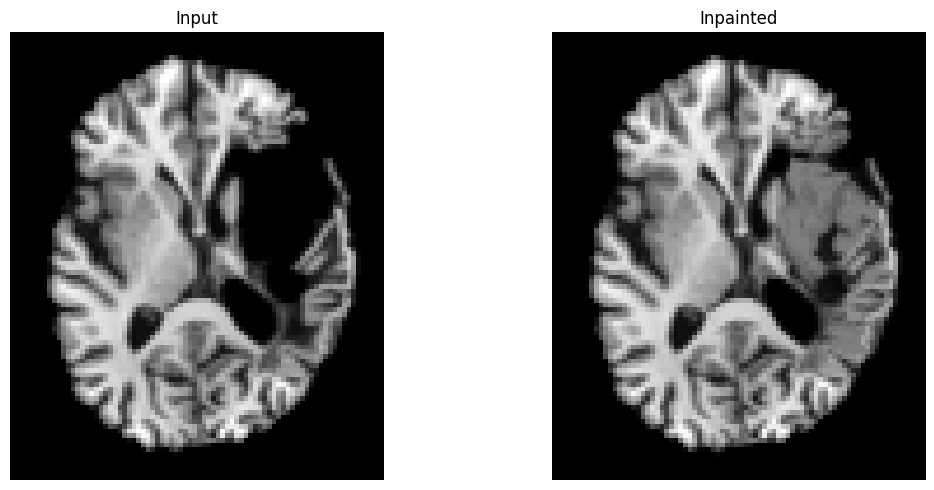

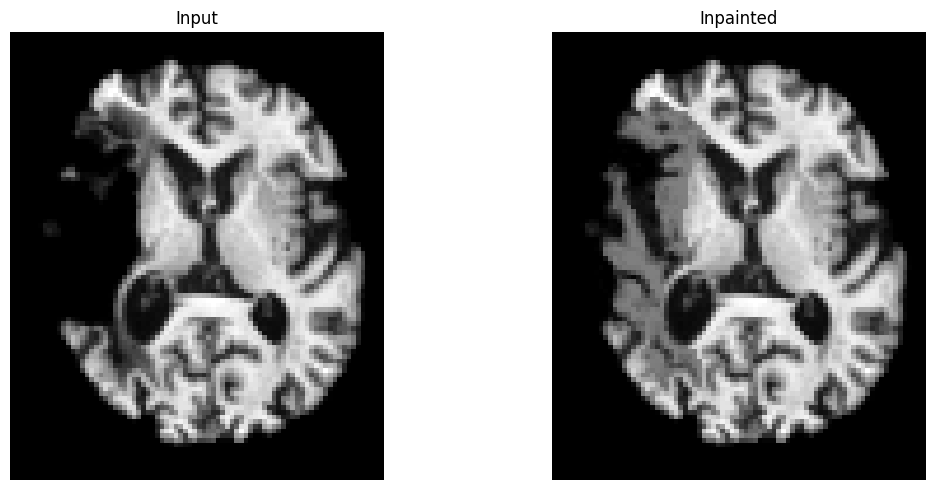

In [10]:
import os
from glob import glob
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/scratch1/zamzam/Strokes/inpainted/"

# Find all saved inputs (brain) and match their inpainted counterparts
t1w_files = sorted(glob(os.path.join(OUT_DIR, "*_T1w.nii.gz")))

if len(t1w_files) == 0:
    raise RuntimeError(f"No *_T1w.nii.gz files found in: {OUT_DIR}")

for t1_path in t1w_files:
    base = Path(t1_path).name.replace("_T1w.nii.gz", "")
    inp_path = os.path.join(OUT_DIR, f"{base}_inpainted.nii.gz")

    if not os.path.exists(inp_path):
        print(f"[SKIP] Missing inpainted for {Path(t1_path).name}: {inp_path}")
        continue

    # Read both NIfTIs
    t1_nii = nib.load(t1_path)
    inp_nii = nib.load(inp_path)

    t1 = t1_nii.get_fdata(dtype=np.float32)     # (H, W, D)
    inp = inp_nii.get_fdata(dtype=np.float32)   # (H, W, D)

    # Middle slice along D
    middle_slice_idx = t1.shape[2] // 2

    # Plot side by side (match your style)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(
        np.rot90(t1[:, :, middle_slice_idx], k=-1),
        vmin=0, vmax=2, cmap="gray"
    )
    axs[0].set_title("Input")
    axs[0].axis("off")

    axs[1].imshow(
        np.rot90(inp[:, :, middle_slice_idx], k=-1),
        vmin=0, vmax=2, cmap="gray"
    )
    axs[1].set_title("Inpainted")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


In [12]:
from monai.networks.nets import UNet

# Path to registration model weights
reg_model_path = "/scratch1/zamzam/3D_Image_Registration/model_weights_1subject_atlas/"

# Find the latest weights file by epoch number
latest_reg_weights_path = max(
    (
        os.path.join(reg_model_path, f)
        for f in os.listdir(reg_model_path)
        if f.startswith("reg") and f.endswith(".pth")
    ),
    key=lambda x: int(x.split("reg")[-1].split(".pth")[0]),
    default=None,
)

# Load the registration model
reg = torch.nn.DataParallel(
    UNet(
        spatial_dims=3,
        in_channels=2,
        out_channels=3,
        channels=(8, 16, 32, 64, 128),
        strides=(2, 2, 2, 2),
        num_res_units=2,
    )
)
if latest_reg_weights_path:
    reg.load_state_dict(torch.load(latest_reg_weights_path))
    print(f"Loaded registration model from {latest_reg_weights_path}")
else:
    raise FileNotFoundError("No registration model weights found.")

reg.to(device).eval();

Loaded registration model from /scratch1/zamzam/3D_Image_Registration/model_weights_1subject_atlas/reg100.pth
